# Lab 3: Four Slots
**ADSA 8035, Week 3** | Estimated time: about 3 hours | Due Sunday, September 20, 11:59 PM ET

---

> **From:** Dr. Ellen Marsh, Head of Medical
> **To:** you
> **Cc:** Dana Whitmore
> **Sent:** Monday, 08:14
>
> Dana says the feature layer is live. Good. Here is what I need from it.
>
> I have capacity to put four players on an individualised load protocol for the next eight weeks. Four. Not six, not "anyone at risk." Each slot costs sessions, minutes, and an argument with the manager, so I want the four names most likely to become a long absence, and I want to be able to defend each one in a room where the manager is not in a philosophical mood.
>
> For each name: why, in plain language. Not a coefficient. Something like "three previous injuries and back within six weeks of the last one."
>
> Tell me where you drew the line and why there, because I will be asked. And tell me what would make you wrong, because I will be asked that too.
>
> I know the model is new. Say how much to trust it. I would rather have four names and an honest caveat than twelve names and a promise.
>
> Thursday.

---

That is the lab. Four names, a line, a reason each, and an honest sentence about how good the model is. The features are Dana's layer from Lab 2. The model, the odds table, the list, and the memo are yours.

The session showed you the ending: the first model barely works. Ellen already knows that. What she is asking is whether you can be useful anyway.

## Setup (provided)

The feature layer from Week 2, the load, the modeling frame, and a stratified split. Everything after this is you.

Note what the modeling frame does: rows with no known outcome are documented out, not deleted. They cannot teach the model, and they are noted in your memo.

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression

import warnings
warnings.filterwarnings('ignore')

# Set global font size for figures
plt.rcParams.update({'font.size': 12})


def parse_injury_date(value):
    if pd.isna(value):
        return pd.NaT
    text = str(value).strip()
    if text.lower() == "present":
        return pd.NaT
    text = text.replace(",", ", ").replace("  ", " ")
    for fmt in ("%b %d, %Y", "%B %d, %Y"):
        try:
            return pd.to_datetime(text, format=fmt)
        except (ValueError, TypeError):
            continue
    return pd.NaT


FIRST_INJURY_FILL = 365
MUSCLE_WORDS = "hamstring|calf|groin|muscle|thigh|strain|quad|adductor"
JOINT_WORDS = "knee|ankle|ligament|cruciate|meniscus|shoulder|hip|foot|toe"
BONE_WORDS = "fracture|broken|metatarsal|collarbone|rib"
HEAD_ILL_WORDS = "concussion|head|illness|virus|corona|covid|ill"


def build_features(df):
    """Feature layer v2.0. See the Week 2 deep dive for the register this docstring mirrors."""
    out = df.copy()
    out["injury_date"] = out["Date of Injury"].apply(parse_injury_date)
    out["return_date"] = out["Date of return"].apply(parse_injury_date)
    out["days_out"] = (out["return_date"] - out["injury_date"]).dt.days
    out["date_error"] = (out["days_out"] < 0) | (out["days_out"] > 1000)
    out.loc[out["date_error"], "days_out"] = np.nan
    out = out.sort_values(["Name", "injury_date", "Injury"]).copy()
    out["prior_injuries"] = out.groupby("Name").cumcount()
    gap = out.groupby("Name")["injury_date"].diff().dt.days
    out["first_injury"] = gap.isna().astype(int)
    out["days_since_last"] = gap.fillna(FIRST_INJURY_FILL).clip(upper=FIRST_INJURY_FILL)
    text = out["Injury"].str.lower().fillna("")
    out["body_region"] = np.select(
        [text.str.contains(MUSCLE_WORDS), text.str.contains(JOINT_WORDS),
         text.str.contains(BONE_WORDS), text.str.contains(HEAD_ILL_WORDS)],
        ["muscle", "joint", "bone", "head_or_illness"], default="other")
    before_cols = [c for c in out.columns if "before_injury_Result" in c]
    points = {"win": 3, "draw": 1, "lose": 0}
    out["form_before"] = (out[before_cols].replace(points)
                          .apply(pd.to_numeric, errors="coerce").mean(axis=1))
    prev_region = out.groupby("Name")["body_region"].shift(1)
    out["recurrence"] = (out["body_region"] == prev_region).astype(int)
    out["long_absence"] = (out["days_out"] > 30).astype(int)
    return out

In [3]:
injury_df = pd.read_csv("https://drive.google.com/uc?export=download&id=1Uaftofu7Ygip2-LOmdyGqQGjK_Ci6QWh", na_values=["N.A."])
features_df = build_features(injury_df)
model_df = features_df.dropna(subset=["days_out", "form_before"]).copy()

numeric_features = ["Age", "FIFA rating", "prior_injuries", "days_since_last", "form_before", "recurrence", "first_injury"]
categorical_features = ["Position", "body_region"]
features = numeric_features + categorical_features

x_train, x_test, y_train, y_test = train_test_split(
    model_df[features], model_df["long_absence"],
    test_size=0.25, random_state=42, stratify=model_df["long_absence"])

# Keep names alongside the test rows so the list has people on it
names_test = model_df.loc[x_test.index, ["Name", "Injury", "injury_date"]]

print("Modeling rows: " + str(len(model_df)) + "   (documented out: " + str(len(features_df) - len(model_df)) + ")")
print("Training: " + str(len(x_train)) + "   Test: " + str(len(x_test)))
print("Base rate of long absence: " + str(round(model_df["long_absence"].mean(), 3)))

Modeling rows: 606   (documented out: 50)
Training: 454   Test: 152
Base rate of long absence: 0.411


## Part 1: Make the Inputs Model-Ready (20 min)

Numbers and categories need different treatment. `StandardScaler` puts every numeric feature on the same footing (mean 0, standard deviation 1), so a coefficient on `Age` and a coefficient on `days_since_last` can be compared. `OneHotEncoder` turns each category into its own 0/1 column.

Build a `ColumnTransformer` that does both. Two rules, and the check enforces them:

- **Fit on training data only.** The scaler learns the mean and standard deviation from `x_train`, then applies them to `x_test`. If the test set influences the scaler, that is leakage, and Week 5 shows you exactly how much it costs.
- **`handle_unknown="ignore"`** on the encoder, so a position that appears only in the test set does not crash the transform.

Then transform both sets and pull the feature names out with `get_feature_names_out()`.

In [4]:
# TODO: build column_trans, fit on x_train only, transform both sets, extract feature_names

column_trans = ColumnTransformer([
    ("scaler", StandardScaler(), numeric_features),
    ("one_hot", OneHotEncoder(handle_unknown="ignore"), categorical_features),
])

x_train_scaled = column_trans.fit_transform(x_train)   # fit on train only
x_test_scaled = column_trans.transform(x_test)         # test just gets transformed
feature_names = column_trans.get_feature_names_out()

In [5]:
# CHECK 1
if "x_train_scaled" in dir() and "feature_names" in dir():
    xt = np.asarray(x_train_scaled.todense() if hasattr(x_train_scaled, "todense") else x_train_scaled)
    assert xt.shape[0] == len(x_train), "Row count changed. The transformer should not drop rows."
    assert xt.shape[1] == len(feature_names), "Column count does not match feature_names."
    assert not np.isnan(xt).any(), "NaNs in the transformed training data. Check form_before or the encoder."
    num_cols = [i for i, n in enumerate(feature_names) if n.startswith("scaler__")]
    assert abs(xt[:, num_cols].mean()) < 0.05, "Numeric columns are not centered. Was the scaler fit on x_train?"
    print("Check 1 passes. " + str(xt.shape[1]) + " model inputs, scaled and encoded.")
else:
    print("Part 1 not built yet.")

Check 1 passes. 26 model inputs, scaled and encoded.


## Part 2: Fit the Model and Build the Odds Table (25 min)

Fit `LogisticRegression` on the transformed training data. Then build the table that makes this model different from a black box: one row per input, with its coefficient and its **odds multiplier**, which is `exp(coefficient)`.

Read the session again if the two steps blur: the coefficient lives on the log-odds scale; the multiplier is what you say out loud. A multiplier of 1.4 means "this feature, one standardised unit higher, multiplies the odds of a long absence by 1.4, holding everything else fixed."

Sort the table by multiplier, largest first.

In [6]:
# TODO: fit logistic_regression; build odds_df with columns feature, coefficient, odds_multiplier; sort

logistic_regression = LogisticRegression(max_iter=1000)
logistic_regression.fit(x_train_scaled, y_train)

odds_df = pd.DataFrame({"feature": feature_names, "coefficient": logistic_regression.coef_[0]})
odds_df["odds_multiplier"] = np.exp(odds_df["coefficient"])
odds_df = odds_df.sort_values("odds_multiplier", ascending=False).reset_index(drop=True)
print(odds_df.round(3).to_string(index=False))

                                feature  coefficient  odds_multiplier
             one_hot__body_region_joint        0.726            2.067
              one_hot__body_region_bone        0.601            1.824
     one_hot__Position_Right Midfielder        0.572            1.773
 one_hot__Position_Defensive Midfielder        0.533            1.704
           one_hot__Position_Right Back        0.515            1.674
                   scaler__first_injury        0.407            1.503
                 scaler__prior_injuries        0.293            1.340
   one_hot__Position_Central Midfielder        0.245            1.278
            one_hot__body_region_muscle        0.245            1.278
           one_hot__Position_Goalkeeper        0.161            1.175
                     scaler__recurrence        0.143            1.154
          one_hot__Position_Center Back        0.120            1.128
                    scaler__form_before        0.089            1.094
  one_hot__Position_

In [7]:
coef = odds_df.set_index("feature")["coefficient"]
n = x_train["body_region"].value_counts()

print("joint:", round(float(np.exp(coef["one_hot__body_region_joint"])), 2), "  rows:", n["joint"])
print("head_or_illness:", round(float(np.exp(coef["one_hot__body_region_head_or_illness"])), 2), "  rows:", n["head_or_illness"])
print("muscle vs joint:", round(float(np.exp(coef["one_hot__body_region_muscle"] - coef["one_hot__body_region_joint"])), 2),
      "  muscle rows:", n["muscle"], "  joint rows:", n["joint"])

joint: 2.07   rows: 134
head_or_illness: 0.3   rows: 48
muscle vs joint: 0.62   muscle rows: 192   joint rows: 134


In [8]:
# CHECK 2
if "odds_df" in dir():
    assert set(["feature", "coefficient", "odds_multiplier"]) <= set(odds_df.columns), "odds_df needs feature, coefficient, odds_multiplier."
    assert len(odds_df) == len(feature_names), "One row per model input."
    assert (odds_df["odds_multiplier"] > 0).all(), "Multipliers must be positive. Did you exp() the coefficient?"
    assert np.allclose(np.exp(odds_df["coefficient"]), odds_df["odds_multiplier"], atol=0.01), "odds_multiplier should be exp(coefficient)."
    assert odds_df["odds_multiplier"].is_monotonic_decreasing, "Sort by multiplier, largest first."
    print("Check 2 passes. Biggest multiplier: " + odds_df.iloc[0]["feature"] + " at " + str(odds_df.iloc[0]["odds_multiplier"]))
else:
    print("Part 2 not built yet.")

Check 2 passes. Biggest multiplier: one_hot__body_region_joint at 2.0670870492843956


**Look at the table before you go on.** Which multipliers are near 1.0? Those features are doing almost nothing, and the session warned you to expect that. Which are furthest from 1.0, in either direction? Those are your headlines. And notice the one-hot rows: a multiplier on `body_region_bone` is relative to the baseline category, not to zero.

## Part 3: Three Coach Sentences (20 min)

Ellen does not want a table. She wants sentences. Write three, one each:

1. The feature with the **largest** multiplier.
2. The feature with the **smallest** multiplier (below 1.0, the protective one).
3. One **categorical** feature, said relative to its baseline.

Model phrasing: *"Players with a previous injury in the same body region carry about 1.3 times the odds of a long absence, holding everything else fixed."* Plain nouns. No column names. And if a multiplier is near 1.0, say that honestly: "this feature barely moves the odds."

Two traps to avoid, both of which will cost you marks. Do not say "adds 30 percent to his risk"; the odds multiplier is not a probability change, and Lecture 1's slider showed you why. And check the count behind any one-hot category before you build a sentence on it: a multiplier of 1.98 on bone injuries is a different claim if it rests on twelve rows than on a hundred and twelve.

**Sentence 1 (largest multiplier):**

**Largest Multiplier:** Players with joint injuries carry about twice the the odds of a long absence compared with other kinds of injuries, holding everything else fixed, and this rests on 134 joint injuries in the training data.

**Sentence 2 (smallest multiplier):**

**Smallest multiplier:** Players with a concussion or an illness carry about 0.3 times the odds of a long absence compared with other kinds of injury, holding everything else fixed, though this rests on a smaller group of 48 injuries.

**Sentence 3 (a categorical feature, relative to baseline):**

**Categorical feature:** Compared with a joint injury, a muscle injury carries about 0.6 times the odds of a long absence, holding everything else fixed, with 192 muscle and 134 joint injuries behind that comparison.

## Part 4: The List (45 min)

Now the part Ellen actually asked for. Four names.

Predict a probability for every injury in the **test set**. Then choose a cutoff and produce the four highest-risk names above it. For each: the probability, and the two features that pushed it highest, in plain language.

A helper is provided for the "two features" part. It computes each row's contribution per input: `coefficient × scaled value`. The two largest contributions for a row are the reasons for that row.

**Decisions you must make and defend below:**

- **The cutoff.** The session showed you that 0.5 may flag nobody. Where do you draw the line, and why there? If you use the base rate, say so.
- **Then the uncomfortable question.** Print how many injuries sit above your line. It will be far more than four. So ask honestly: is the cutoff doing any work here, or is the ranking doing all of it while the cutoff decorates the memo? Lecture 2 said the model's job is to rank so a human with four slots can choose. If that is what is happening, say so in the memo rather than pretending the line picked the four.
- **Why four.** Ellen said four. Print the fifth name, and if it is a coin flip away from the fourth, say that.

**One rule about names:** these are real players. Describe what the data shows (previous injuries, gap, region). Do not speculate about their medical condition. That is Ellen's job, not yours, and getting it wrong in writing is how analysts get removed from rooms.

In [9]:
def contributions(model, x_scaled, names):
    """One row per injury, one column per model input: coefficient times scaled value.
    The largest values in a row are the reasons that row's probability is high."""
    dense = np.asarray(x_scaled.todense() if hasattr(x_scaled, "todense") else x_scaled)
    return pd.DataFrame(dense * model.coef_[0], columns=names)

PLAIN = {
    "prior_injuries": "a long injury history",
    "days_since_last": "recently back from the last one",
    "first_injury": "no previous injury on record",
    "recurrence": "same body part as last time",
    "form_before": "club had been losing",
    "Age": "younger than the squad average",
    "FIFA rating": "a highly rated player",
    "body_region_bone": "a bone injury",
    "body_region_joint": "a joint injury",
    "body_region_muscle": "a muscle injury",
    "body_region_head_or_illness": "illness or a head injury",
    "body_region_other": "an unclassified injury",
}

def plain(name):
    key = name.replace("scaler__", "").replace("one_hot__", "")
    if key.startswith("Position_"):
        return "plays " + key.split("_", 1)[1].lower()
    return PLAIN.get(key, key.replace("_", " "))

def top_two_reasons(contrib_row):
    top = contrib_row.sort_values(ascending=False).head(2)
    return ", ".join(plain(name) for name in top.index)

In [10]:
# TODO: predict test probabilities; choose CUTOFF; build the_list with exactly four rows:
#       Name, Injury, prob, reasons (use contributions + top_two_reasons)
CUTOFF = None

PLAIN["FIFA rating"] = "a lower-rated player"     # your table has FIFA rating below 1.0
PLAIN["form_before"] = "club had been winning"    # and form_before above 1.0

scored = names_test.copy()
scored["prob"] = logistic_regression.predict_proba(x_test_scaled)[:, 1]
scored["actual_long"] = y_test                    # Part 5 needs this

contrib = contributions(logistic_regression, x_test_scaled, feature_names)
scored["reasons"] = [top_two_reasons(contrib.iloc[i]) for i in range(len(contrib))]

CUTOFF = round(float(y_train.mean()), 3)          # base rate of long absence in training data

ranked = scored.sort_values("prob", ascending=False).drop_duplicates("Name")   # one row per player
the_list = ranked.head(4)[["Name", "Injury", "prob", "reasons"]]
print(the_list.round(3).to_string(index=False))

print("Cutoff:", CUTOFF)
print("Above cutoff:", (scored["prob"] >= CUTOFF).sum(), "of", len(scored))
print("Above cutoff + 0.02:", (scored["prob"] >= CUTOFF + 0.02).sum())
print("Fifth name:", ranked.iloc[4]["Name"], round(ranked.iloc[4]["prob"], 3))


            Name                Injury  prob                               reasons
    Oliver Skipp            Hip injury 0.867  a lower-rated player, a joint injury
Giovani Lo Celso           Knee injury 0.733 a long injury history, a joint injury
     Joe Willock           Knee injury 0.730  a joint injury, a lower-rated player
  Matthew Lowton ankle and knee injury 0.687      a joint injury, plays right back
Cutoff: 0.412
Above cutoff: 68 of 152
Above cutoff + 0.02: 62
Fifth name: Kortney Hause 0.687


In [11]:
# CHECK 4
if "the_list" in dir() and CUTOFF is not None:
    assert len(the_list) == 4, "Ellen asked for four. You have " + str(len(the_list)) + "."
    assert set(["Name", "prob", "reasons"]) <= set(the_list.columns), "Each row needs Name, prob, reasons."
    assert (the_list["prob"] >= CUTOFF).all(), "Every name must be at or above your cutoff."
    assert the_list["prob"].is_monotonic_decreasing, "Sort highest risk first."
    assert the_list["reasons"].str.len().min() > 3, "Every name needs reasons."
    print("Check 4 passes. Four names above " + str(CUTOFF) + ".")
else:
    print("Part 4 not built yet, or CUTOFF not set.")

Check 4 passes. Four names above 0.412.


In [12]:
print(scored["actual_long"].mean(), scored[scored["prob"] >= scored["prob"].quantile(0.75)]["actual_long"].mean())

0.40789473684210525 0.47368421052631576


**Your cutoff, defended (3 to 4 sentences):** where is the line, whose number is it, how many injuries sit above it, and what happens to the four names if it moves by 0.02? If the answer is "nothing, because capacity binds long before the line does," that is the right answer and it belongs in the memo.

**My point:** I put the line at 0.412 which is just the base rate: 41% of injuries in the training data turned into long absences. That number comes from the data, not from me. In the test set, 68 of 152 injuries sit above it, which is way more than four, and nudging the line up by 0.02 only drops that to 62. All four names stay put either way, since the lowest of them scores 0.687. So the line isnt really picking anyone. The ranking does the work, and Ellens four slots decide where we stop.

**Why these four and not five (1 to 2 sentences):**

**My point:** Ellen said four, so four it is. I can see why the question because the fith player Kortney Hause scores 0.687, the same as number four. So picking between them can be difficult.

## Part 5: Confidently Wrong (15 min)

Find one injury in the test set where the model was **confidently wrong**: a high probability that turned out to be a short absence, or a low probability that became a long one. Print the row.

Then argue, in 3 to 4 sentences, what the model could not see. Not "the model was wrong." What information, that a physio would have had, was not in the feature layer?

This is your first error analysis. It is the seed of next week's Technical Report.

In [13]:
# TODO: find one confidently-wrong row and print it with its probability and actual outcome

scored["miss"] = (scored["actual_long"] - scored["prob"]).abs()
print(scored.sort_values("miss", ascending=False).head(5)[["Name", "Injury", "prob", "actual_long"]].round(2))

worst = scored["miss"].idxmax()
print(model_df.loc[worst, ["Name", "Injury", "injury_date", "days_out", "Position", "Age", "body_region",
                           "prior_injuries", "days_since_last", "form_before", "recurrence"]])

                   Name             Injury  prob  actual_long
416        Oliver Skipp         Hip injury  0.87            0
373  Christian Norgaard        Back injury  0.14            1
365        Jadon Sancho         depression  0.16            1
348      Edinson Cavani  Tendon irritation  0.17            1
433         Hugo Lloris       Elbow injury  0.18            1
Name                       Oliver Skipp
Injury                       Hip injury
injury_date         2019-11-09 00:00:00
days_out                           25.0
Position           Defensive Midfielder
Age                                  19
body_region                       joint
prior_injuries                        0
days_since_last                   365.0
form_before                    2.333333
recurrence                            0
Name: 416, dtype: object


**What the model could not see (3 to 4 sentences):**

**My point:** The worst miss is Oliver Skipp's hip injury in November 2019. The model gave it a 0.87 probability of a long absence, and he was back in 25 days, five short of the 30-day line. All the model had was the label "hip injury" (which it grouped as a joint injury) his age and rating, and that it was his first injury on record. It couldnt see how severe the injury was, what the scan showed or how the medical staff planned to bring him back, and a physio would have known all three early on.

## Part 6: The Assumption Check (20 min)

Logistic regression assumes each feature's effect is a **straight line on the log-odds scale**. Not on the probability scale; on log-odds. It is a real constraint, and you can check it in four lines.

Pick one numeric feature. Cut it into five bins with roughly equal counts (`pd.qcut`). For each bin, compute the empirical share of long absences, convert to log-odds with `log(p / (1 - p))`, and plot bin centre against log-odds. If the points march in a straight line, the assumption holds. If they bend, the model is fitting a line through a curve, and Week 9 shows you the fix.

**One trap if you pick `days_since_last`:** a third of the rows sit at exactly 365, the fill value for first injuries. That is not data, it is a placeholder, and it will swallow your quantile bins. Exclude first injuries before you bin, or pick a different feature.

              bin   n     share  centre  log_odds
0  (-0.001, 50.0]  67  0.388060    34.0 -0.455476
1    (50.0, 88.6]  65  0.446154    70.0 -0.216223
2   (88.6, 143.4]  66  0.424242   114.5 -0.305382
3  (143.4, 229.4]  66  0.409091   182.5 -0.367725
4  (229.4, 364.0]  66  0.378788   305.5 -0.494696


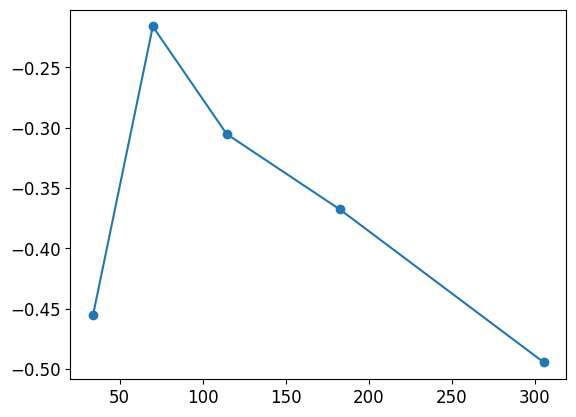

In [14]:
# TODO: five quantile bins of one numeric feature, empirical log-odds per bin, one plot

# Drop first injuries and gaps clipped at 365 (placeholders that break the bins)
sub = model_df[(model_df["first_injury"] == 0) & (model_df["days_since_last"] < 365)].copy()
sub["bin"] = pd.qcut(sub["days_since_last"], 5)

by_bin = sub.groupby("bin", observed=True).agg(
    n=("long_absence", "size"),
    share=("long_absence", "mean"),
    centre=("days_since_last", "median")).reset_index()
by_bin["log_odds"] = np.log(by_bin["share"] / (1 - by_bin["share"]))
print(by_bin)

plt.plot(by_bin["centre"], by_bin["log_odds"], "o-")
plt.show()

In [15]:
# CHECK 6
if "by_bin" in dir():
    assert len(by_bin) >= 4, "Need at least 4 bins to see a shape."
    assert "log_odds" in by_bin.columns, "Compute log_odds per bin."
    assert (by_bin["n"] >= 10).all(), "A bin with fewer than 10 rows cannot tell you anything."
    print("Check 6 passes. " + str(len(by_bin)) + " bins, smallest has " + str(int(by_bin["n"].min())) + " rows.")
else:
    print("Part 6 not built yet.")

Check 6 passes. 5 bins, smallest has 65 rows.


**Verdict (2 sentences):** does the assumption hold for your feature, and where does the line bend most?

**Verdict** It does but not cleanly. The points rise from the shortest gaps (under 50 days) to the 50 to 89 day bin, then slide down steadily

## Part 7: The Memo to Ellen (25 min)

She reads the first paragraph. Structure it that way.

**Paragraph 1:** the four names, one plain-language reason each, and the probability. That is the recommendation.

**Paragraph 2:** where the line is, whose number set it, and what happens if it moves. If it is the base rate, say so and say why.

**Paragraph 3:** how much to trust this. Be specific and be honest. The session showed you the single-feature model barely worked. Say what the full model can and cannot separate. If a fifth name is within a coin flip of the fourth, say that here.

**Paragraph 4:** what would make you wrong. The one thing a physio knows that this model does not.

Six to nine sentences. No code. No column names without a plain-language gloss.

**MEMO TO DR. ELLEN MARSH, HEAD OF MEDICAL**
**Memo:** The four names: Oliver Skipp (hip injury, joint injury, 0.87) Giovani Lo Celso (knee injury, long injury history, 0.73) Joe Willock (knee injury, joint injury 0.73) and Mathew Lowton (ankle and knee injury, joint injury, 0.69)

The line is 0.412, the base rate of long absences in the training data, not a number i picked. 68 of 152 test injuries clear it, so the ranking picks these four, not the line, moving it 0.02. This either way does not change dosent change the list. The fith name Kortney Hause, scores 0.687 same as Lowton to three decimals, essentially a coin flip.

I do trust it but only so far. Overall, about 41% of test injuries became long abesences. In the top quarter by predicted risk, that rises to about 47%. Thats a real signal, but not a big one. The models own top pick, Skipp's, was actually a 25-day absence, five days under our cutoff. It has no access to scans, severity or the treatment plan. This is a problem when a serious in jury and a minor injury with the same label score the same.

What would make me wrong, a physios eyes on the injury. Having more access to imaging, exam findings or the management plan would have told a different story for Skipp, and could for any of these four too.

## Stretch (optional, and it changes the list)



Refit with `LogisticRegression(class_weight="balanced")`. That tells the model to care equally about both outcomes even though one is rarer. Rebuild the list at the same cutoff.

Did the four names change? Did the probabilities spread out? Which list would you rather defend to Ellen, and why? Two sentences in your memo if you do this

In [16]:
# STRETCH: class_weight="balanced", refit, rebuild the list, compare


## AI-Use Disclosure (required)

If an AI wrote any of your model code, run the check cells on it before you read it. That is the two-minute habit. Then answer all five, briefly. "I did not use AI this week" is a complete answer.

1. What did you use AI for, and with which tools?
2. What were your most important prompts?
3. What did the AI get wrong, or what did you change from its output?
4. Where did your human judgment come in?
5. What are you still unsure about?

**Memo:**

I did rely on AI a bit more for this assigment to create a strucutre and to understand a bit more about what we were asked to do. As alwasy to trouble shoot code and just to understand some part of the code better.

I feel the most important was asking to walk me through each part and to interpret some of the results. I feel since its soccer i do understand a bit more than other sports.

I flagged that on the two PLAIN phrases (FIFA rating and form_before) it had pointed the wrong direction for my model, which i corrected it

I chose to note the Skipp near-miss and the coin-flip between name four and five rather than let the numbers imply more precision than they have; and I'm the one deciding what final wording goes in front of Ellen.

The one that i was still unsure about is how heavy to rely on the four names as they lean on the same feature  (joint injury).

## Submission Checklist

- [ ] Every cell runs top to bottom without errors
- [ ] All four CHECK cells print a pass
- [ ] Three coach sentences, plain nouns, no column names
- [ ] The list has exactly four names with reasons a physio could read; the cutoff is defended, including whether it does any work
- [ ] One confidently-wrong row with a 3 to 4 sentence argument
- [ ] Assumption check with a verdict
- [ ] Memo: four names in paragraph one, the line, the honest trust sentence, what would make you wrong
- [ ] AI-Use Disclosure completed
- [ ] Share link: Anyone with the link, Viewer, tested in an incognito window

## How This Is Graded

| Criterion | Points | What earns full marks |
|---|---|---|
| Inputs and model build to spec | 20 | Checks 1 and 2 pass; scaler fit on train only; odds table correct and sorted |
| Coach sentences | 15 | Three sentences, plain language, honest about near-1.0 multipliers |
| The list and the line | 25 | Four names with reasons a physio could read, not column names; cutoff defended and its owner named; honest about whether the line or the ranking does the work |
| Error story and assumption check | 15 | A specific missing piece of information, not "the model was wrong"; a verdict on linearity |
| The memo | 25 | Four names in paragraph one; the line; a specific trust statement; what would make you wrong |

Not on the rubric: how good the model is. It is not very good, and you know why. On the rubric: whether Ellen could act on Thursday, and whether she would still trust you in March.